In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
%cd /content/gdrive/My Drive/570project/
# if you want to run the code, you need to change this path to your directory

Mounted at /content/gdrive
/content/gdrive/My Drive/570project


# Global parameter

In [2]:
N = 5  
K = 5  
Q = 5  
E_train = 500 
E_test = 50

In [3]:
!pip install easyfsl
# codes about data and Net are modified from https://github.com/sicara/easy-few-shot-learning

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.8 MB/s eta 0:00:00


# Model

In [4]:
import torch
from torch import nn

## network

In [5]:
class PrototNet(nn.Module):
    def __init__(self, FE):
        super(PrototNet, self).__init__()
        self.FE = FE
    def forward(self,images_K,labels_K,images_Q):
        features_K = self.FE.forward(images_K)
        features_Q = self.FE.forward(images_Q)
        cluster_idx = torch.nonzero(labels_K == 0)
        prototypes = torch.mean(features_K[cluster_idx],dim=0)
        for i in range(1,len(torch.unique(labels_K))):
          cluster_idx = torch.nonzero(labels_K == i)
          prototype_i = torch.mean(features_K[cluster_idx],dim=0)
          prototypes = torch.cat((prototypes,prototype_i))        
        return - torch.cdist(features_Q, prototypes)

## train

In [6]:
def train(model,optimizer,criterion,train_loader):
  losses = 0
  model.train()
  data = iter(train_loader)
  for i in range(len(train_loader)):
    images_K,labels_K,images_Q,labels_Q,_ = next(data)
    images_K = images_K.to('cuda')
    labels_K = labels_K.to('cuda')
    images_Q = images_Q.to('cuda')
    labels_Q = labels_Q.to('cuda')

    pred_dis = model(images_K, labels_K, images_Q)

    loss = criterion(pred_dis, labels_Q)
    losses += loss.item()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  return losses/len(train_loader)

## evaluate

In [7]:
def evaluate(model, data_loader):
    total = 0
    corrects = 0
    model.eval()
    data = iter(data_loader)
    with torch.no_grad():
      for i in range(len(data_loader)):
        images_K,labels_K,images_Q,labels_Q,_ = next(data)
        images_K = images_K.to('cuda')
        labels_K = labels_K.to('cuda')
        images_Q = images_Q.to('cuda')
        labels_Q = labels_Q.to('cuda')

        pred = model(images_K, labels_K, images_Q)

        pred_labels = torch.max(pred,1)[1]
        correct = (pred_labels == labels_Q).sum()

        total += len(labels_Q)
        corrects += correct.detach().item()
    return corrects/total

# Dataset

In [8]:
#!git clone https://github.com/sicara/easy-few-shot-learning # run 1 times
%cd /content/gdrive/My Drive/570project/easy-few-shot-learning
#!bash scripts/download_CUB.sh # run 1 times
from torchvision import transforms
from easyfsl.datasets import CUB
from torch.utils.data import DataLoader
from easyfsl.samplers import TaskSampler

/content/gdrive/My Drive/570project/easy-few-shot-learning


In [9]:
def CUB_loader(transform_train,transform_test,image_size):
  train_set = CUB(split="train", training=True,image_size=image_size,transform= transform_train)
  train_sampler = TaskSampler(train_set, n_way=N, n_shot=K, n_query=Q, n_tasks=E_train)
  train_loader = DataLoader(train_set,batch_sampler=train_sampler,num_workers=12,pin_memory=True,collate_fn=train_sampler.episodic_collate_fn)

  test_set = CUB(split="val", training=False,image_size=image_size,transform= transform_test )
  test_sampler = TaskSampler(test_set, n_way=N, n_shot=K, n_query=Q, n_tasks=E_test)
  test_loader = DataLoader(test_set,batch_sampler=test_sampler,num_workers=12,pin_memory=True,collate_fn=test_sampler.episodic_collate_fn)

  return train_loader, test_loader

# Data augmentation

In [10]:
transform_train0 = transforms.Compose([transforms.Resize((224,224)),
                     transforms.ToTensor(),
                     transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),])
transform_test0 = transforms.Compose([transforms.Resize((224,224)),                                   
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),])

In [11]:
train_loader0, test_loader0 = CUB_loader(transform_train0,transform_test0,image_size = 224)

In [12]:
transform_train = transforms.Compose([ transforms.RandomResizedCrop(224),                 
                     transforms.RandomHorizontalFlip(),
                     transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),                     
                     transforms.ToTensor(),
                     transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),])
transform_test = transforms.Compose([transforms.Resize((224,224)),                                   
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),])

In [13]:
train_loader, test_loader = CUB_loader(transform_train,transform_test, 224)

In [14]:
transform_train2 = transforms.Compose([transforms.RandomResizedCrop(256),
                     transforms.RandomHorizontalFlip(),
                     transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),                  
                     transforms.ToTensor(),
                     transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),])
transform_test2 = transforms.Compose([transforms.Resize((256,256)),                 
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),])

In [15]:
train_loader2, test_loader2 = CUB_loader(transform_train2,transform_test, 256)

# Training

In [16]:
from torch import optim
n_epochs = 100

## densenet121

In [17]:
from torchvision.models import densenet121
FE = densenet121()
FE.classifier = nn.Flatten()
model = PrototNet(FE).cuda()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_loss=[]
test_acc=[]
for epoch in range(n_epochs):
    print("Epoch {}".format(epoch))
    loss = train(model,optimizer,nn.CrossEntropyLoss(),train_loader)
    acc = evaluate(model, test_loader)*100
    train_loss.append(loss)
    test_acc.append(acc)
    print("train loss = {} test acc = {}".format(loss,acc))

Epoch 0
train loss = 1.5582801160812378 test acc = 40.48
Epoch 1
train loss = 1.448123879790306 test acc = 47.92
Epoch 2
train loss = 1.407671925663948 test acc = 49.12
Epoch 3
train loss = 1.3618314278125763 test acc = 55.04
Epoch 4
train loss = 1.2948584926128388 test acc = 59.36
Epoch 5
train loss = 1.2853182398080827 test acc = 55.84
Epoch 6
train loss = 1.2346074858903884 test acc = 59.36
Epoch 7
train loss = 1.1799914795160293 test acc = 62.08
Epoch 8
train loss = 1.1504869967699052 test acc = 63.04
Epoch 9
train loss = 1.0966892638802528 test acc = 62.88
Epoch 10
train loss = 1.0516407011151314 test acc = 66.56
Epoch 11
train loss = 1.029828326046467 test acc = 65.6
Epoch 12
train loss = 1.0169189408421517 test acc = 66.4
Epoch 13
train loss = 0.9676791269183159 test acc = 66.72
Epoch 14
train loss = 0.9584328402280807 test acc = 72.72
Epoch 15
train loss = 0.9564864319562912 test acc = 71.52
Epoch 16
train loss = 0.9195022419691086 test acc = 69.12
Epoch 17
train loss = 0.90291

## convnext_tiny

In [20]:
from torchvision.models import convnext_tiny
FE = convnext_tiny()
FE.classifier = nn.Flatten()
model = PrototNet(FE).cuda()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_loss2=[]
test_acc2=[]
for epoch in range(n_epochs):
    print("Epoch {}".format(epoch))
    loss = train(model,optimizer,nn.CrossEntropyLoss(),train_loader2)
    acc = evaluate(model, test_loader2)*100
    train_loss2.append(loss)
    test_acc2.append(acc)
    print("train loss = {} test acc = {}".format(loss,acc))

Epoch 0
train loss = 1.7393515243530273 test acc = 35.36
Epoch 1
train loss = 1.534012647151947 test acc = 35.52
Epoch 2
train loss = 1.5236103241443635 test acc = 35.2
Epoch 3
train loss = 1.5048666677474976 test acc = 38.24
Epoch 4
train loss = 1.4944358804225921 test acc = 38.24
Epoch 5
train loss = 1.483390167236328 test acc = 41.36
Epoch 6
train loss = 1.465321209669113 test acc = 40.8
Epoch 7
train loss = 1.4601810956001282 test acc = 40.64
Epoch 8
train loss = 1.4503051451444626 test acc = 43.6
Epoch 9
train loss = 1.433761006951332 test acc = 40.96
Epoch 10
train loss = 1.4108624869585038 test acc = 46.08
Epoch 11
train loss = 1.370650236725807 test acc = 54.16
Epoch 12
train loss = 1.3603724339008332 test acc = 49.28
Epoch 13
train loss = 1.3423108845949172 test acc = 54.24
Epoch 14
train loss = 1.318381612420082 test acc = 52.16
Epoch 15
train loss = 1.3010148550271987 test acc = 58.4
Epoch 16
train loss = 1.2932938586473466 test acc = 58.24
Epoch 17
train loss = 1.2608627848

## resnet18

In [18]:
from torchvision.models import resnet18
FE = resnet18()
FE.fc = nn.Flatten()
model = PrototNet(FE).cuda()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_loss3=[]
test_acc3=[]
for epoch in range(n_epochs):
    print("Epoch {}".format(epoch))
    loss = train(model,optimizer,nn.CrossEntropyLoss(),train_loader)
    acc = evaluate(model, test_loader)*100
    train_loss3.append(loss)
    test_acc3.append(acc)
    print("without attention: train loss = {} test acc = {}".format(loss,acc))

Epoch 0
without attention: train loss = 1.610613467335701 test acc = 42.48
Epoch 1
without attention: train loss = 1.4625342435836792 test acc = 44.08
Epoch 2
without attention: train loss = 1.4072147862911224 test acc = 45.84
Epoch 3
without attention: train loss = 1.378549656391144 test acc = 54.56
Epoch 4
without attention: train loss = 1.34777188539505 test acc = 50.4
Epoch 5
without attention: train loss = 1.2798230081796647 test acc = 51.36
Epoch 6
without attention: train loss = 1.2516456983089448 test acc = 55.44
Epoch 7
without attention: train loss = 1.201146735548973 test acc = 57.84
Epoch 8
without attention: train loss = 1.1573916274309157 test acc = 61.84
Epoch 9
without attention: train loss = 1.107474278330803 test acc = 62.96
Epoch 10
without attention: train loss = 1.0677093614935875 test acc = 68.08
Epoch 11
without attention: train loss = 1.0457522250413895 test acc = 60.64
Epoch 12
without attention: train loss = 1.0200830094814302 test acc = 67.68
Epoch 13
without

In [ ]:
import matplotlib.pyplot as plt

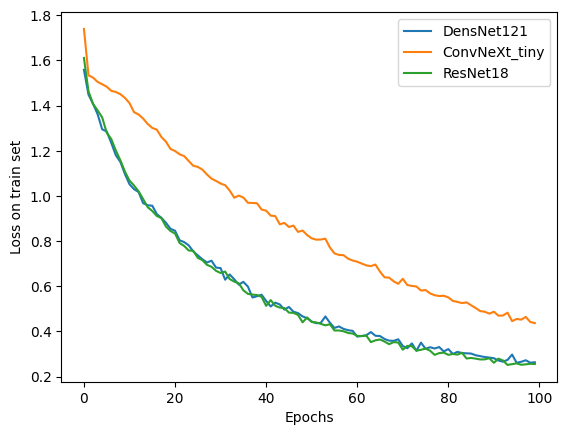

In [ ]:
x = range(100)
plt.plot(x, train_loss, label = "DensNet121")
plt.plot(x, train_loss2, label = "ConvNeXt_tiny")
plt.plot(x, train_loss3, label = "ResNet18")

plt.xlabel("Epochs")
plt.ylabel("Loss on train set")
plt.legend()
plt.show()

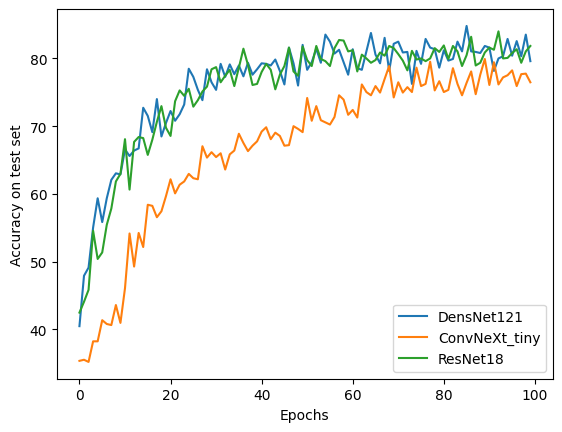

In [ ]:
plt.plot(x, test_acc, label = "DensNet121")
plt.plot(x, test_acc2, label = "ConvNeXt_tiny")
plt.plot(x, test_acc3, label = "ResNet18")
plt.xlabel("Epochs")
plt.ylabel("Accuracy on test set")
plt.legend()
plt.show()

## densenet121 without data augmentation

In [ ]:
FE = densenet121()
FE.classifier = nn.Flatten()
model = PrototNet(FE).cuda()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loss=[]
test_acc=[]
for epoch in range(n_epochs):
    print("Epoch {}".format(epoch))
    loss = train(model,optimizer,nn.CrossEntropyLoss(),train_loader0)
    acc = evaluate(model, test_loader0)*100
    train_loss.append(loss)
    test_acc.append(acc)
    print("train loss = {} test acc = {}".format(loss,acc))

Epoch 0
train loss = 1.4232359745502472 test acc = 48.96
Epoch 1
train loss = 1.1855340760946274 test acc = 52.08
Epoch 2
train loss = 1.0371656527519226 test acc = 57.36
Epoch 3
train loss = 0.8934964438974857 test acc = 69.04
Epoch 4
train loss = 0.7943900257050991 test acc = 67.92
Epoch 5
train loss = 0.6916206848323345 test acc = 71.6
Epoch 6
train loss = 0.6222405576407909 test acc = 71.12
Epoch 7
train loss = 0.5649182019978761 test acc = 71.2
Epoch 8
train loss = 0.4803341412246227 test acc = 70.72
Epoch 9
train loss = 0.43918010576069355 test acc = 69.04
Epoch 10
train loss = 0.37960987673699853 test acc = 73.6
Epoch 11
train loss = 0.3568483604602516 test acc = 71.52
Epoch 12
train loss = 0.31397336043044927 test acc = 73.12
Epoch 13
train loss = 0.28778993626032023 test acc = 72.48
Epoch 14
train loss = 0.24108299640752376 test acc = 71.52
Epoch 15
train loss = 0.23848299295827746 test acc = 73.84
Epoch 16
train loss = 0.216460564524401 test acc = 73.28
Epoch 17
train loss = 

## resnet18 without data augmentation

In [ ]:
FE = resnet18()
FE.fc = nn.Flatten()
model = PrototNet(FE).cuda()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loss3=[]
test_acc3=[]
for epoch in range(n_epochs):
    print("Epoch {}".format(epoch))
    loss = train(model,optimizer,nn.CrossEntropyLoss(),train_loader0)
    acc = evaluate(model, test_loader0)*100
    train_loss3.append(loss)
    test_acc3.append(acc)
    print("without attention: train loss = {} test acc = {}".format(loss,acc))

Epoch 0
without attention: train loss = 1.47674689745903 test acc = 39.76
Epoch 1
without attention: train loss = 1.2932827599048615 test acc = 49.2
Epoch 2
without attention: train loss = 1.0424595640897751 test acc = 63.36
Epoch 3
without attention: train loss = 0.9057476830482483 test acc = 66.88
Epoch 4
without attention: train loss = 0.7920214529335499 test acc = 66.16
Epoch 5
without attention: train loss = 0.6486457693427801 test acc = 70.24
Epoch 6
without attention: train loss = 0.559018984541297 test acc = 66.96
Epoch 7
without attention: train loss = 0.4902639658525586 test acc = 67.52
Epoch 8
without attention: train loss = 0.42306744470074775 test acc = 67.44
Epoch 9
without attention: train loss = 0.32320183132588864 test acc = 69.36
Epoch 10
without attention: train loss = 0.25135728539898994 test acc = 74.16
Epoch 11
without attention: train loss = 0.21289041083492338 test acc = 70.08
Epoch 12
without attention: train loss = 0.17635371275618672 test acc = 68.88
Epoch 13

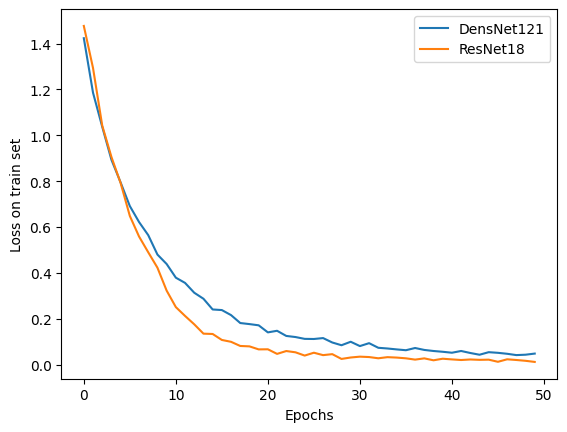

In [ ]:
x = range(50)
plt.plot(x, train_loss, label = "DensNet121")
plt.plot(x, train_loss3, label = "ResNet18")

plt.xlabel("Epochs")
plt.ylabel("Loss on train set")
plt.legend()
plt.show()

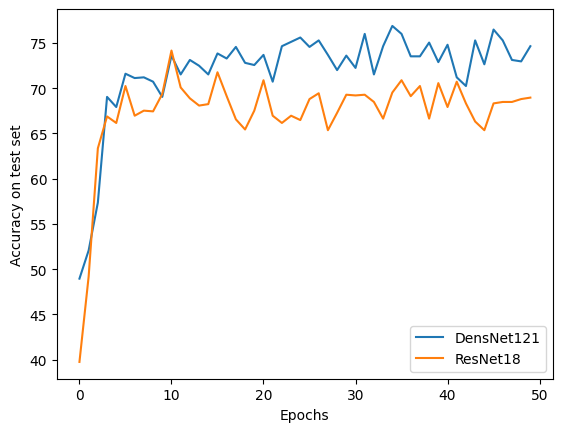

In [ ]:
plt.plot(x, test_acc, label = "DensNet121")
plt.plot(x, test_acc3, label = "ResNet18")
plt.xlabel("Epochs")
plt.ylabel("Accuracy on test set")
plt.legend()
plt.show()